This page aims to experiment with warmup lengths on two different MVNs.

In [1]:
!pip install -Uq tfp-nightly[jax]
!pip install inference_gym
!pip install tf-nightly

# remember to restart runtime after changing the environment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 623.5/623.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 33.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requi

**Package Import and other setups**

In [1]:
import numpy as np
from copy import deepcopy
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

# from matplotlib.pyplot import *

import os
# in case jax eats up my GPU RAM
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
from jax import random
from jax import numpy as jnp

# from inference_gym import using_jax as gym

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
from inference_gym import using_jax as gym
tfb = tfp.bijectors

from tensorflow_probability.substrates import numpy as tfp_np
tfd_np = tfp_np.distributions

import matplotlib.pyplot as plt

import pandas as pd

import gc

# check if this is run on a gpu
print(jax.devices())
print(jax.default_backend())

import warnings
warnings.filterwarnings('ignore')

import psutil

process = psutil.Process(os.getpid())

def mem(msg):
    print(f"{msg}: {process.memory_info().rss / 1024**2:.1f} MB")

[CudaDevice(id=0)]
gpu


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
utility_link = '/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/utility.py'
with open(utility_link) as f: exec(f.read())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/utility.py'

In [3]:
def kernel_setup(warmup_length, sampling_length,
                 num_sub_chains,num_super_chains,
                 naive, initialize_fn,ranKey,
                 target_log_prob_fn, init_step_size):
  num_warmup_short, num_sampling_short = warmup_length, sampling_length
  total_samples_short = num_warmup_short + num_sampling_short

  kernel_short = tfp.mcmc.HamiltonianMonteCarlo(target_log_prob_fn, init_step_size, 1)
  kernel_short = tfp.experimental.mcmc.GradientBasedTrajectoryLengthAdaptation(kernel_short, num_warmup_short)
  kernel_short = tfp.mcmc.DualAveragingStepSizeAdaptation(
      kernel_short, num_warmup_short, target_accept_prob = 0.75,  #0.75,
      reduce_fn = tfp.math.reduce_log_harmonic_mean_exp)

  if (naive):
    # initialize each chain at a different location
    initial_state = initialize_fn((num_sub_chains,),key=ranKey)
    initial_state_super = initial_state

  else:
    # Chains within a super chain are all initialized at the same location
    initial_state_super = initialize_fn((num_super_chains,), key=ranKey)
    initial_state = jnp.repeat(initial_state_super, num_sub_chains // num_super_chains,
                            axis = 0)
  return kernel_short, initial_state, total_samples_short, initial_state_super


def _reduce_variance_interval(x, axis=None, biased=True, keepdims=False):
    # ddof=0 is biased variance (N), ddof=1 is unbiased variance (N-1)
    ddof = 0 if biased else 1
    return jnp.var(x, axis=axis, ddof=ddof, keepdims=keepdims)


def nested_rhat_constrained(result_state, num_super_chains,idx):
    # since we use only N=1, W_k is reduced to 0

    num_sub_chains = result_state.shape[0] // num_super_chains
    num_dimensions = result_state.shape[1]

    chain_states = result_state.reshape(1, -1, num_sub_chains, num_dimensions)
    # chain_states.shape = (1,16,128,2)
    # f_bar 1*k is:
    mean_subchain = jnp.mean(chain_states, axis=2)
    # mean_subchain.shape =(1,16,2)

    # f_bar **K is:
    mean_superchain = jnp.mean(mean_subchain, axis=1)
    # mean_superchain.shape = (1,2)

    variance_chain = _reduce_variance_interval(chain_states, axis=2, biased=False)
    # print(variance_chain.shape) # (1,16,2)
    W = jnp.mean(variance_chain, axis=1)
    # print(f"W dim: {W.shape}") # (1,2)
    B = _reduce_variance_interval(mean_subchain, axis=1, biased=False) # variance of between super chain

    r_hat = jnp.sqrt(1+B/W)[:,idx]
    return r_hat


def simulation(keys, initialize_fn,
               warmup_length,sampling_length,
               naive, repitition,
               MSE_list, R_Hat_list,
               num_dim, state_list,
               mean_benchmark,var_benchmark,
               num_super_chains,num_sub_chains,
               target_log_prob_fn, init_step_size):
  result_mse = []
  # very long warmup phase might result in memory issue.
  skip_trace = (warmup_length > 600)

  for sim in range(repitition):
    kernel_short, initial_state, total_samples_short, initial_state_super = kernel_setup(warmup_length,sampling_length,
                                                            num_sub_chains, num_super_chains,
                                                            naive, initialize_fn,keys[sim],
                                                            target_log_prob_fn, init_step_size)
    # print(initial_state.shape)
    # print(f"unique vals in initial state: {jnp.unique(initial_state[:,0])}")
    # print(f"unique vals in initial state: {jnp.unique(initial_state[:,1])}")
    # print(f"initial state super chain: {initial_state_super}")
    if not skip_trace:
      result = tfp.mcmc.sample_chain(
        total_samples_short, initial_state, kernel = kernel_short,
        seed =keys[sim], trace_fn=None)
      result_with_init = jnp.concatenate([initial_state[None, :, :], result],axis=0)
      result_short = result[-1,:,:]
      state_record = {
            "Warmup Length": warmup_length,
            "Iteration": sim,
            "States":np.asarray(result_with_init),
            "Initial Position":np.asarray(initial_state_super)
          }
    else:
       result = []
       result_with_init = []
       result_short = tfp.mcmc.sample_chain(
        total_samples_short, initial_state, kernel = kernel_short,
        seed =keys[sim], trace_fn=None)[-1,:,:]
       state_record = {
            "Warmup Length": warmup_length,
            "Iteration": sim,
            "States":[],
            "Initial Position":[]
          }
    state_list.append(state_record)
    # result_short_shape is (2048, num_dim)
    # print(f"result full shape: {result.shape}")
    # print(f"result with init shape: {result_with_init.shape}")
    # print(f"result_short shape: {result_short.shape}")

    # the f bar
    mc_mean = result_short.mean(axis=0)
    squared_error = (mc_mean - mean_benchmark)**2
    # the factor was in fact 1/var
    factor = 1/var_benchmark
    # sq_err for all dimensions: a vector with dimension=num_dim
    factored_sq_err = factor*squared_error
    # avg over all dimension
    mse = (factored_sq_err).mean()
    result_mse.append(mse)

    for dim in range(num_dim):
      new_r_hat = nested_rhat_constrained(result_short, num_super_chains, dim)
      R_Hat_list.append({
         "Warmup Length": warmup_length,
         "Iteration":sim,
         "Dimension": dim,
         "Rhat": new_r_hat[-1],
         "MSE":factored_sq_err[dim]
      })
    del state_record
    del result_short
    del result
    del kernel_short
    del initial_state
    del initial_state_super
    del total_samples_short
    del result_with_init
    gc.collect()

  # calculation time:
  result_mse = np.array(result_mse)
  result_mse_best = result_mse.min(axis=0)
  result_mse_worst = result_mse.max(axis=0)
  # avg on all simulations
  mean_mse = result_mse.mean(axis=0)

  MSE_list.append({"Warmup Length":warmup_length,
                   "Avg MSE": mean_mse,
                   "Best MSE": result_mse_best,
                   "Worst MSE": result_mse_worst})
  if naive:
    print(f"Naive initialization. Warmup Length: {warmup_length}; mean of MSE is: {mean_mse}")
  else:
    print(f"Constrained initialization. Warmup Length: {warmup_length}; mean of MSE is: {mean_mse}")

  del result_mse
  gc.collect()
  jax.clear_caches()


In [13]:
# plotting functions:
# the plotting function would be based on dfs returned by the simulation
def trace_plot(state_df, iteration,
               DimIdx1, DimIdx2,
               show_chain_num, naive):
    states = state_df["States"][iteration]
    initial_pos = state_df["Initial Position"][iteration]
    num_super_chain = initial_pos.shape[0]
    chains = np.random.choice(states.shape[1], show_chain_num, replace=False)

    plt.figure(figsize=(10, 8), dpi=150)

    for chain in chains:
        trajectory = states[:, chain, :]
        plt.plot(trajectory[:, DimIdx1], trajectory[:, DimIdx2], alpha=0.3, lw=1)
        plt.scatter(trajectory[-1, DimIdx1], trajectory[-1, DimIdx2], s=20)

    if not naive:
        plt.scatter(
            initial_pos[:, DimIdx1],
            initial_pos[:, DimIdx2],
            color="black",
            marker="^",
            s=40,
        )
    plt.xlabel(f"Dimension {DimIdx1}")
    plt.ylabel(f"Dimension {DimIdx2}")
    plt.title(
        f"Iteration: {iteration}, Traceplot of Dim {DimIdx1} and Dim {DimIdx2}, "
        f"{show_chain_num} chains"
    )
    handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="black",
        linestyle="",
        markersize=6,
        label="Endpoint"
    )]
    if not naive:
      handles.append(
        Line2D(
            [0], [0],
            marker="^",
            color="black",
            linestyle="",
            markersize=8,
            label="Starting Point"
        ))

    plt.legend(handles=handles, loc="best")
    plt.show()

def MSE_vs_Warmup(constrained_df, naive_df, title):
  fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

  common = dict(
    logx=True,
    logy=True,
    legend=False,
    ax=ax,
    ylabel="MSE",
    x="Warmup Length",
    )
  ax = constrained_df.plot(
    y="Avg MSE",
    title=title,
    linestyle="-",
    color="orange",
    **common
  )
  constrained_df.plot(
    y="Best MSE",
    linestyle="--",
    color="orange",
    **common
    )
  constrained_df.plot(
    y="Worst MSE",
    linestyle="--",
    color="orange",
    **common)
  naive_df.plot(
    y="Avg MSE",
    linestyle="-",
    color="black",
    **common)
  naive_df.plot(
    y="Worst MSE",
    linestyle="--",
    color="black",
    **common)
  naive_df.plot(
    y="Best MSE",
    linestyle="--",
    color="black",
    **common)
  ax.legend(handles=[
    Line2D([0], [0], color="orange", lw=2, label="Constrained"),
    Line2D([0], [0], color="black", lw=2, label="Naive")])

def MSE_vs_Rhat(
    df,
    title,
    naive,
    bound,
    threshold,
    num_subchains,
    ColorDimension=False,
):

    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

    if ColorDimension:
        ###################################################
        # Color by Dimension (continuous)
        ###################################################

        sc = ax.scatter(
            df["Rhat"],
            df["MSE"],
            c=df["Dimension"],
            cmap="viridis",      # or "turbo"
            s=35,
            alpha=0.4,
        )

        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label("Dimension")

    else:
        ###################################################
        # Color by Warmup Length (discrete)
        ###################################################

        cmap = plt.get_cmap("turbo")

        warmups = np.sort(df["Warmup Length"].unique())

        color_map = {
            w: cmap(x)
            for w, x in zip(
                warmups,
                np.linspace(0, 1, len(warmups))
            )
        }

        groups = df.groupby("Warmup Length")

        for warmup, subset in groups:
            ax.scatter(
                subset["Rhat"],
                subset["MSE"],
                color=color_map[warmup],
                s=35,
                alpha=0.4,
            )

        handles = [
            Line2D(
                [0], [0],
                marker="o",
                color=color,
                linestyle="",
                markersize=8,
                label=str(warmup),
            )
            for warmup, color in color_map.items()
        ]

        ax.legend(
            handles=handles,
            title="Warmup Length",
            loc="lower right",
            ncol=2,          # helpful if you have many warmups
            fontsize=9,
        )

    ###################################################
    # Common formatting
    ###################################################

    ax.set_yscale("log")

    if not naive:
        ax.set_xscale("log")

    ax.axhline(bound[0], color="black", linestyle="--")
    ax.axhline(bound[1], color="black", linestyle="--")
    ax.axhline(1 / num_subchains, color="black")
    ax.axvline(threshold, color="blue", linestyle="--")

    ax.set_xlabel(r"$\widehat{R}_{\nu}$")
    ax.set_ylabel("MSE")

    suffix = "Constrained" if not naive else "Naive"
    ax.set_title(f"{title} - {suffix}")

    plt.tight_layout()
    plt.show()

**Hyperparam Setups**

In [5]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# the total number of chains has been tuned down due to storage issue
repitition = 10
num_chains_short = 512
num_super_chains = 4

In [6]:
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
num_chains_short = 2048
num_super_chains = 16
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1

bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower+1

**MVN with isotropic covariance**

In [ ]:
num_dim = 100
# mean array:
mu = jnp.full(num_dim, 1.3)
# covariance matrix:
cov = jnp.eye(num_dim)
target = tfd.MultivariateNormalFullCovariance(
      loc=jnp.array(mu),
      covariance_matrix=cov)
init_step_size = 0.5
def target_log_prob_fn(x):
    return target.log_prob(x)
def initialize(shape, key):
    return random.normal(key, shape + (num_dim,))
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

mean_benchmark = target.mean()
var_benchmark = target.variance()

In [ ]:
#simulation part:
MSE_constrained_list = []
MSE_naive_list = []
R_Hat_constrained_list = []
R_Hat_naive_list = []
state_list_constrained = []
state_list_naive = []

In [ ]:
# 26 min

for length in warmup_length:
  mem(f"Simulation start")
  simulation(
            keys,initialize,
            length,1,
            False, repitition,
            MSE_constrained_list,R_Hat_constrained_list,
            num_dim, state_list_constrained,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size)
  simulation(
            keys,initialize,
            length,1,
            True, repitition,
            MSE_naive_list,R_Hat_naive_list,
            num_dim, state_list_naive,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size)


Simulation start: 1572.9 MB
Constrained initialization. Warmup Length: 10; mean of MSE is: 0.01761559396982193
Naive initialization. Warmup Length: 10; mean of MSE is: 0.01737087033689022
Simulation start: 2227.5 MB
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.0011870389571413398
Naive initialization. Warmup Length: 20; mean of MSE is: 0.0010458962060511112
Simulation start: 2593.0 MB
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.0005192087264731526
Naive initialization. Warmup Length: 30; mean of MSE is: 0.0005102156428620219
Simulation start: 3117.5 MB
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.0004965230473317206
Naive initialization. Warmup Length: 40; mean of MSE is: 0.00048616837011650205
Simulation start: 3801.9 MB
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.0005208253278397024
Naive initialization. Warmup Length: 50; mean of MSE is: 0.0005108087789267302
Simulation start: 4639.1 MB
Constrained ini

**Save to DataFrame and pickle**

In [ ]:
MSE_c_df = pd.DataFrame(MSE_constrained_list)
R_Hat_c_df = pd.DataFrame(R_Hat_constrained_list)
state_c_df = pd.DataFrame(state_list_constrained)
MSE_n_df = pd.DataFrame(MSE_naive_list)
R_Hat_n_df = pd.DataFrame(R_Hat_naive_list)
state_n_df = pd.DataFrame(state_list_naive)

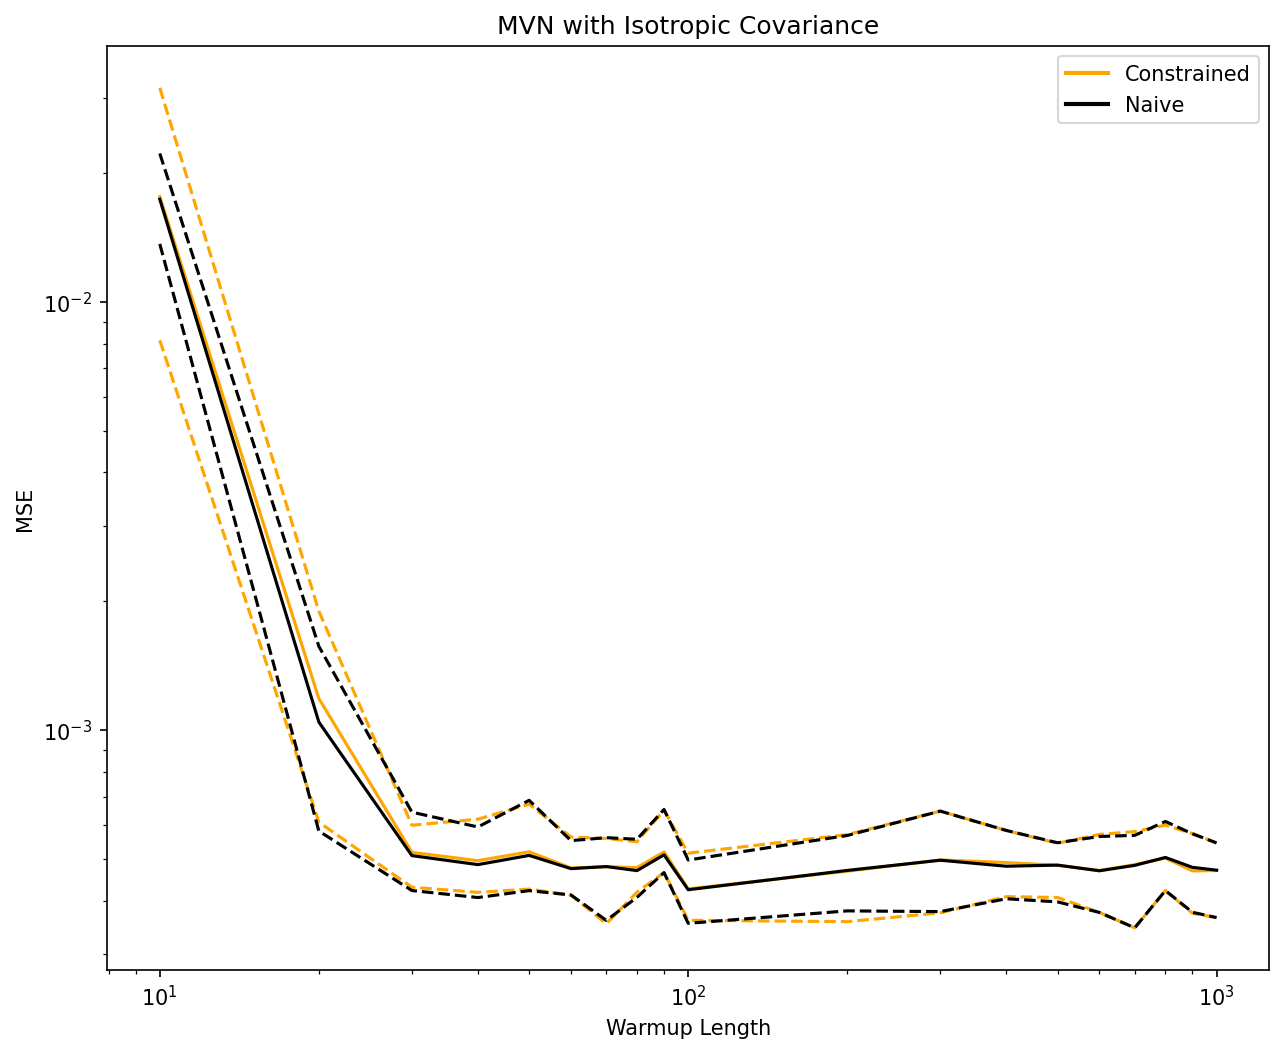

In [ ]:
MSE_vs_Warmup(MSE_c_df,
              MSE_n_df,
              "MVN with Isotropic Covariance")

In [ ]:
R_Hat_c_df.head()

,Warmup Length,Iteration,Dimension,Rhat,MSE
0,10,0,0,1.0067471,0.0126281455
1,10,0,1,1.0072888,0.009784975
2,10,0,2,1.0159992,0.037708655
3,10,0,3,1.0133686,0.008092047
4,10,0,4,1.0098653,0.013388809


In [ ]:
state_c_df.head()

,Warmup Length,Iteration,States,Initial Position
0,10,0,"[[[1.0040143, -0.9063372, -0.7481722, -1.17136...","[[1.0040143, -0.9063372, -0.7481722, -1.171366..."
1,10,1,"[[[-2.4424558, -2.0356805, 0.20554423, -0.3535...","[[-2.4424558, -2.0356805, 0.20554423, -0.35355..."
2,10,2,"[[[1.2956359, 1.3550105, -0.40960556, -0.77188...","[[1.2956359, 1.3550105, -0.40960556, -0.771885..."
3,10,3,"[[[-0.6219436, 0.6248041, 1.6820775, -0.808012...","[[-0.6219436, 0.6248041, 1.6820775, -0.8080128..."
4,10,4,"[[[-1.0208855, 0.60980767, -1.2941693, -0.1214...","[[-1.0208855, 0.60980767, -1.2941693, -0.12144..."


In [ ]:
# Scatter plot schemes
marker_scheme = {
        50: "o",
        80: "s",
        100: "^",
        200: "D",
        500: "*"
    }

    # Color for each warmup length
color_scheme = {
    10: "tab:blue",
    25: "tab:cyan",
    50: "tab:green",
    75: "tab:orange",
    100: "tab:red"
    }


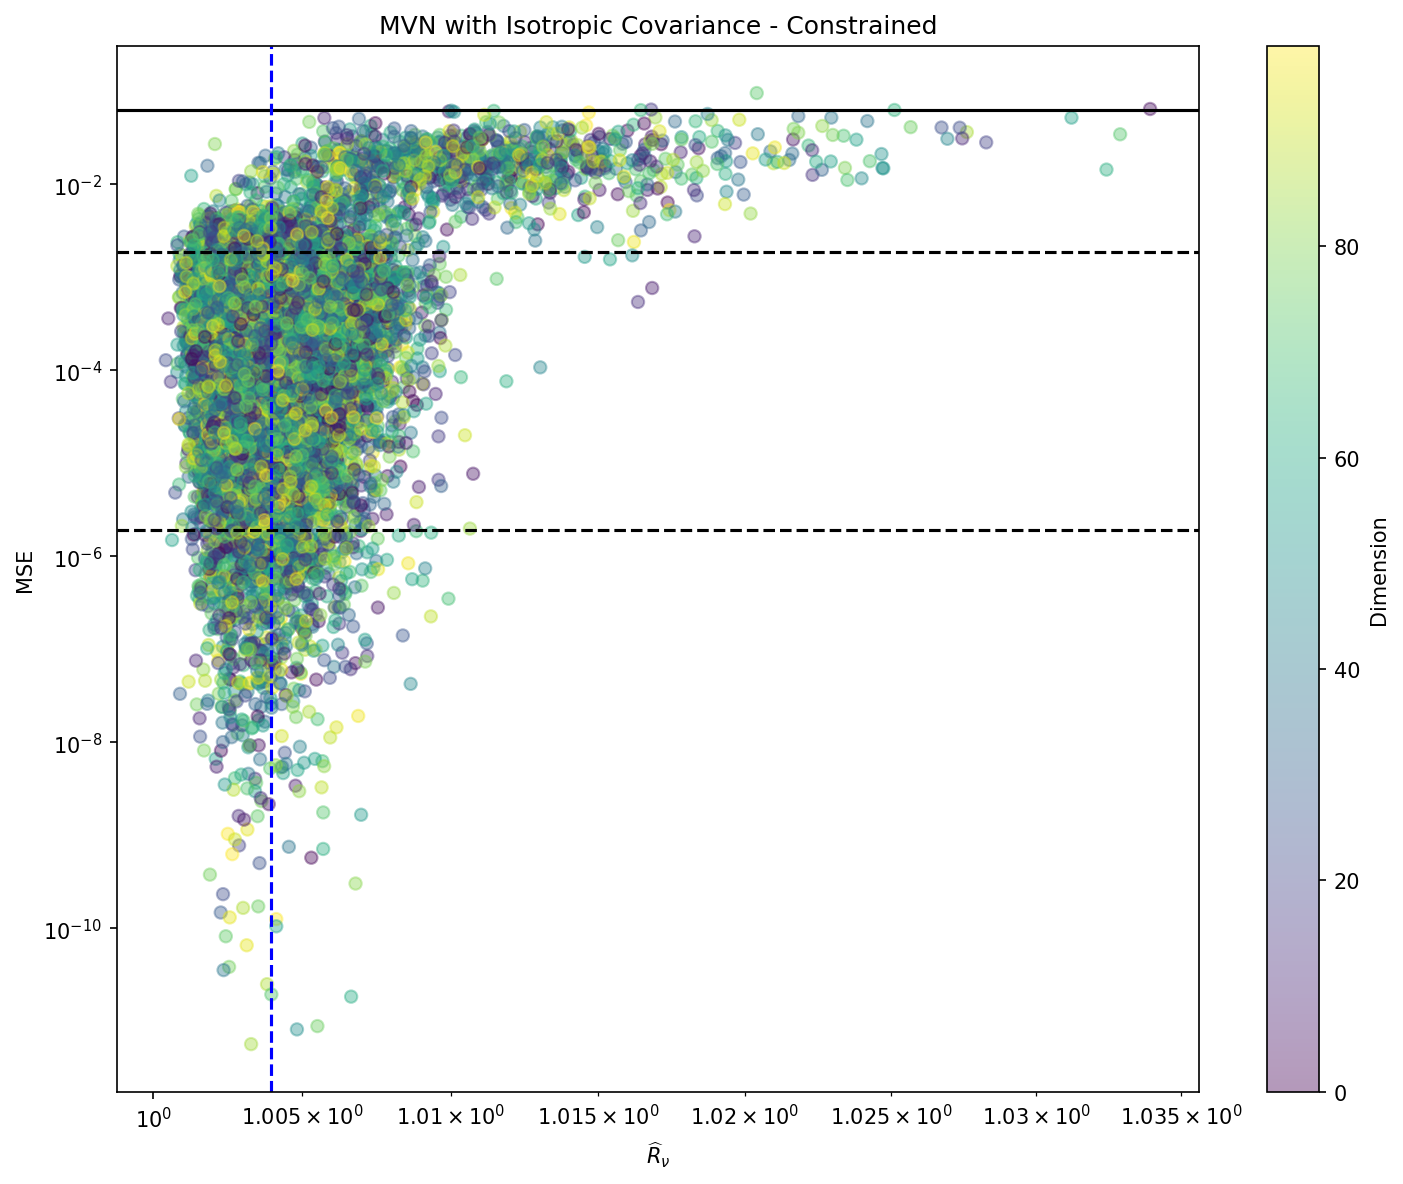

In [ ]:
MSE_vs_Rhat(R_Hat_c_df,
           "MVN with Isotropic Covariance",
           False,
            bound, threshold,num_super_chains,True)

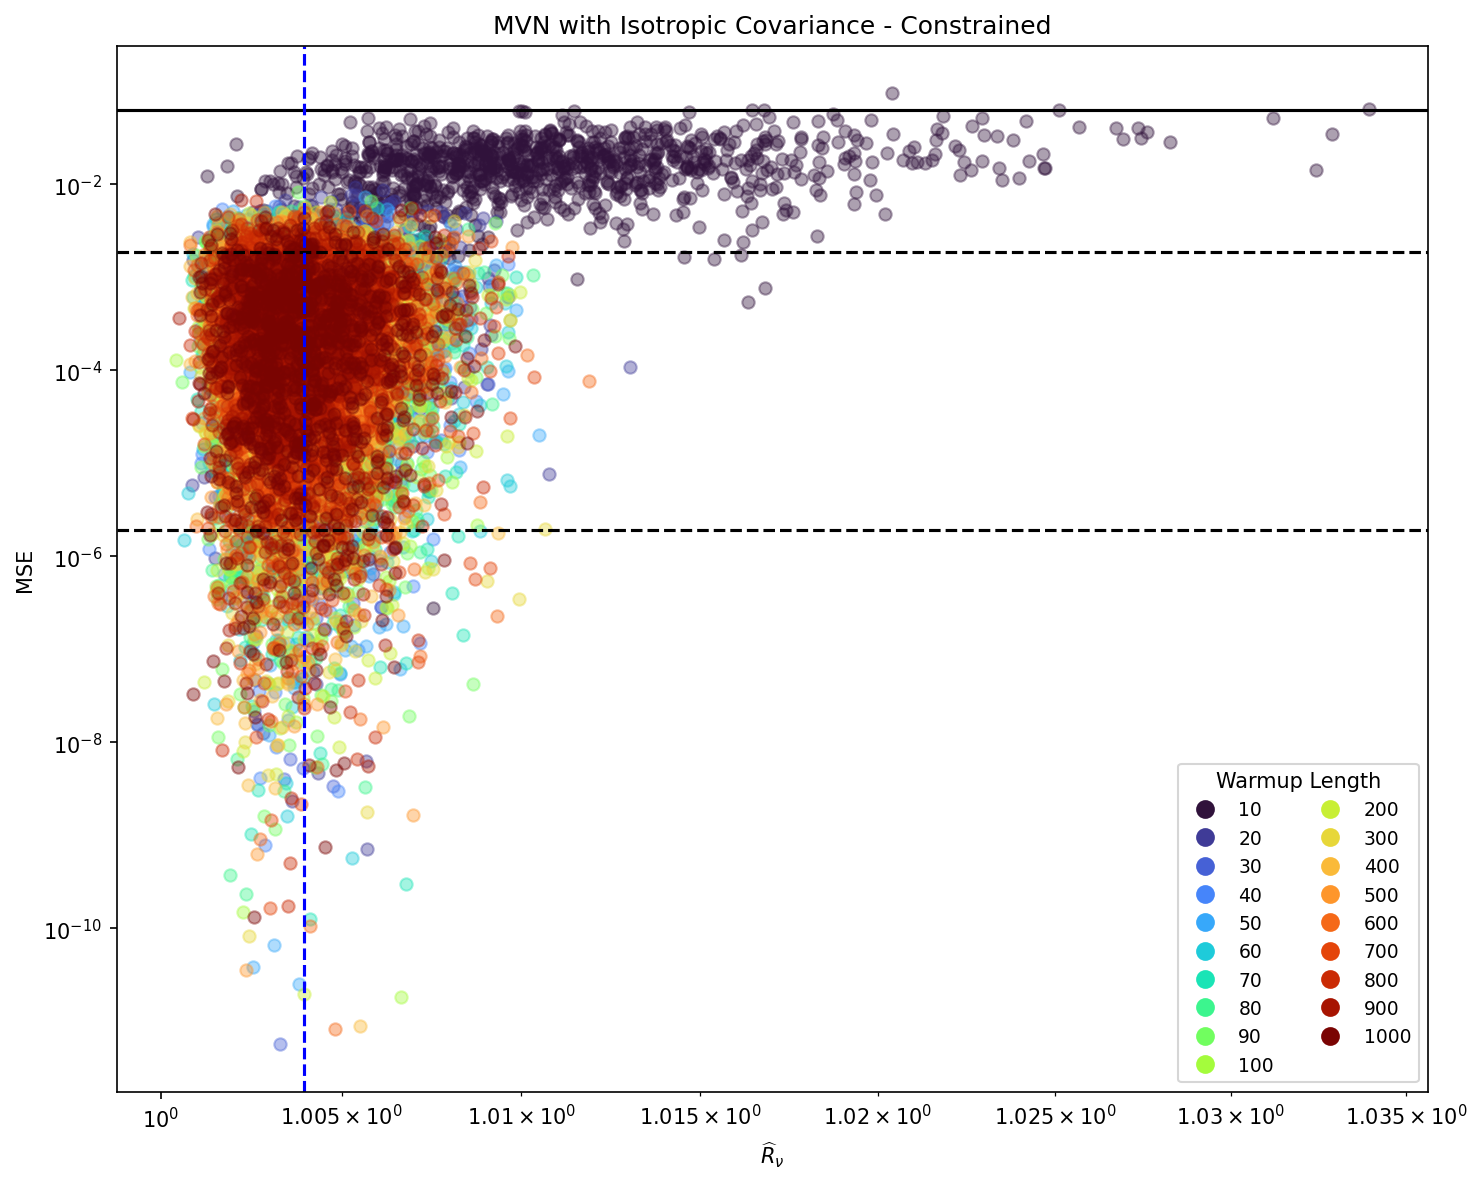

In [ ]:
MSE_vs_Rhat(R_Hat_c_df,
           "MVN with Isotropic Covariance",
           False,
            bound, threshold,num_super_chains,False)

**Is there a preference for certain dimension being above the threshold?**

<Axes: xlabel='Dimension', ylabel='Rhat'>

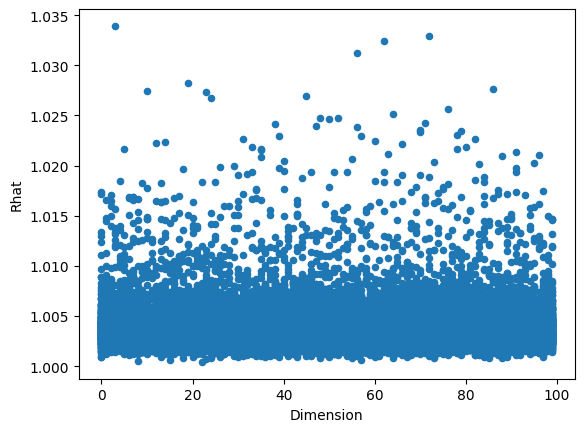

In [ ]:
R_Hat_c_df.plot.scatter('Dimension', 'Rhat')

Well, I guess no. At least not for this one.

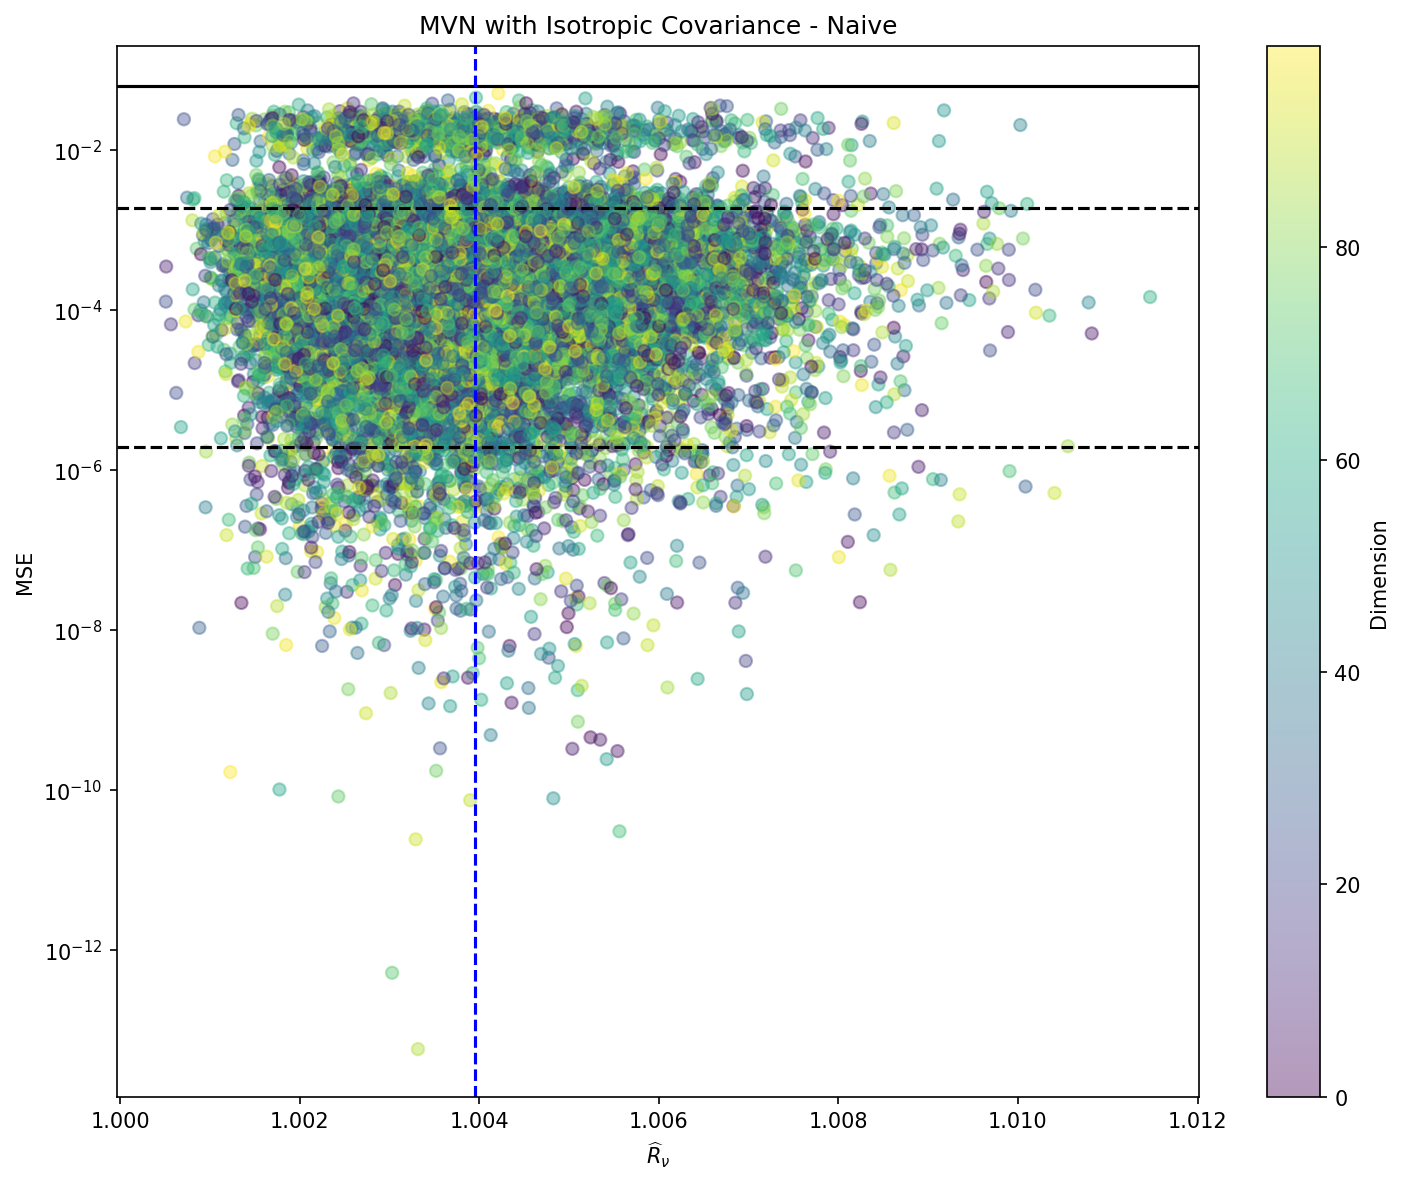

In [ ]:
MSE_vs_Rhat(R_Hat_n_df,
           "MVN with Isotropic Covariance",
           True,
            bound, threshold,num_super_chains,True)

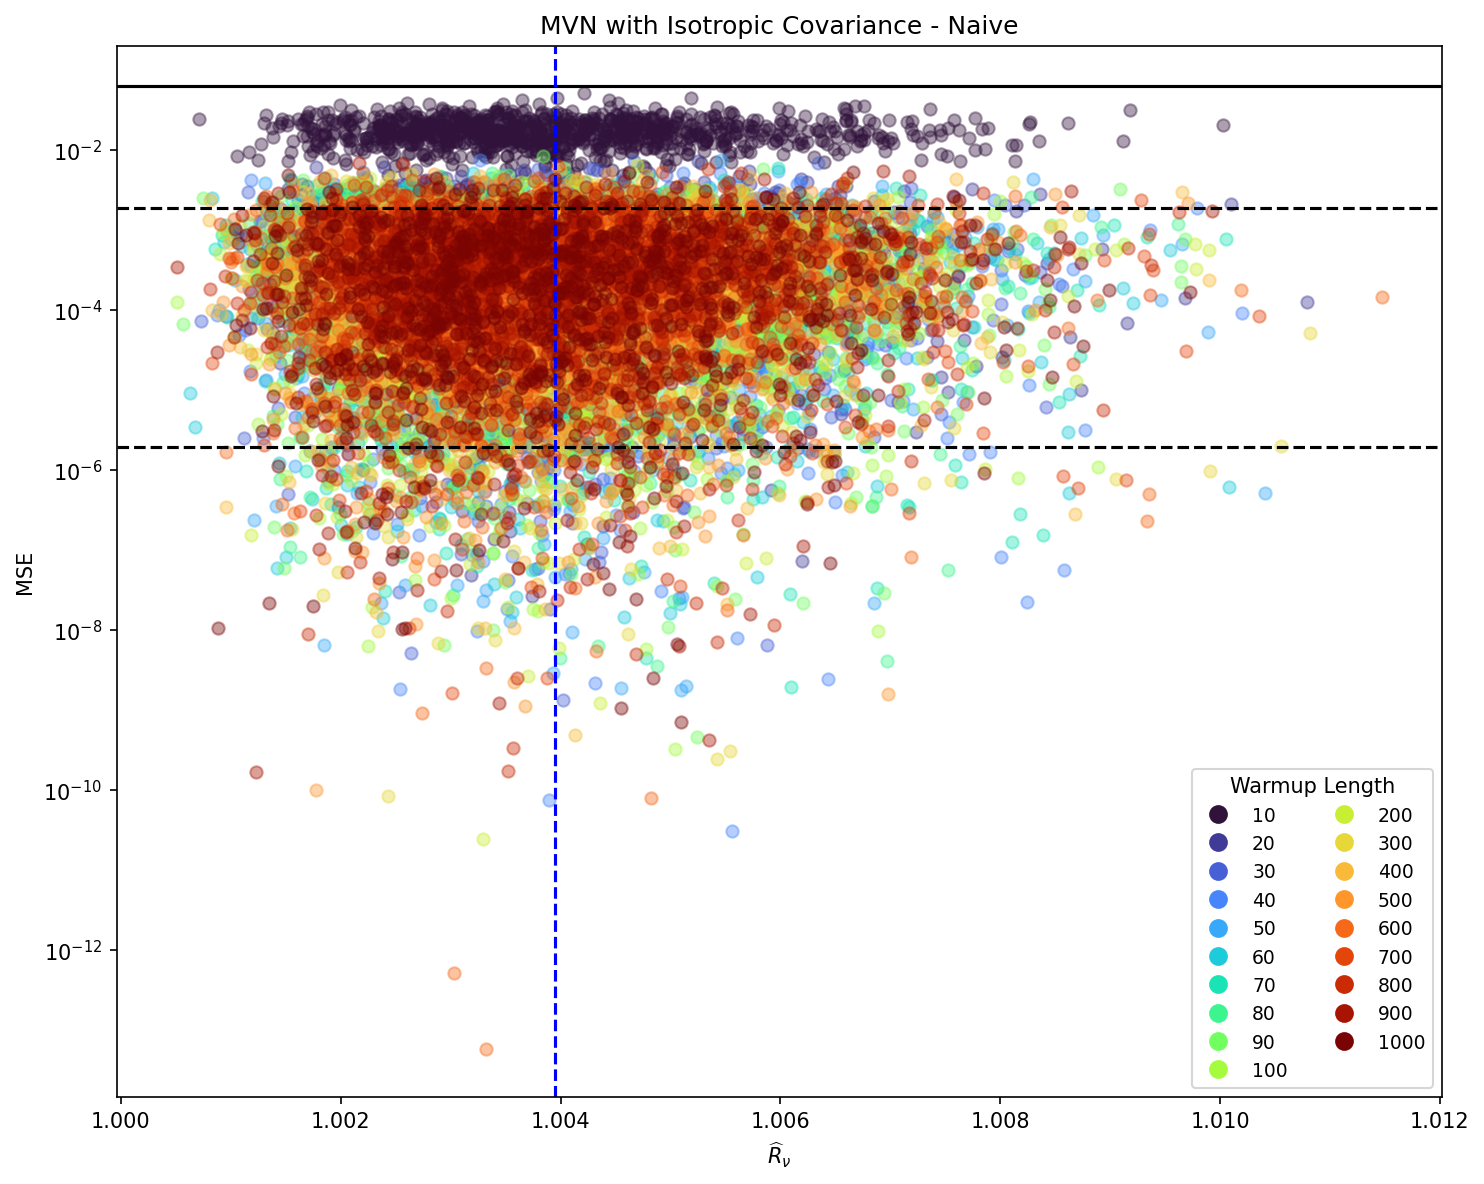

In [ ]:
MSE_vs_Rhat(R_Hat_n_df,
           "MVN with Isotropic Covariance",
           True,
            bound, threshold,num_super_chains,False)

<Axes: xlabel='Dimension', ylabel='Rhat'>

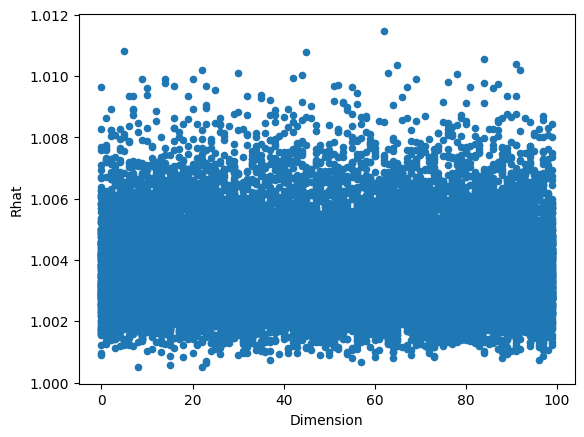

In [ ]:
R_Hat_n_df.plot.scatter('Dimension', 'Rhat')

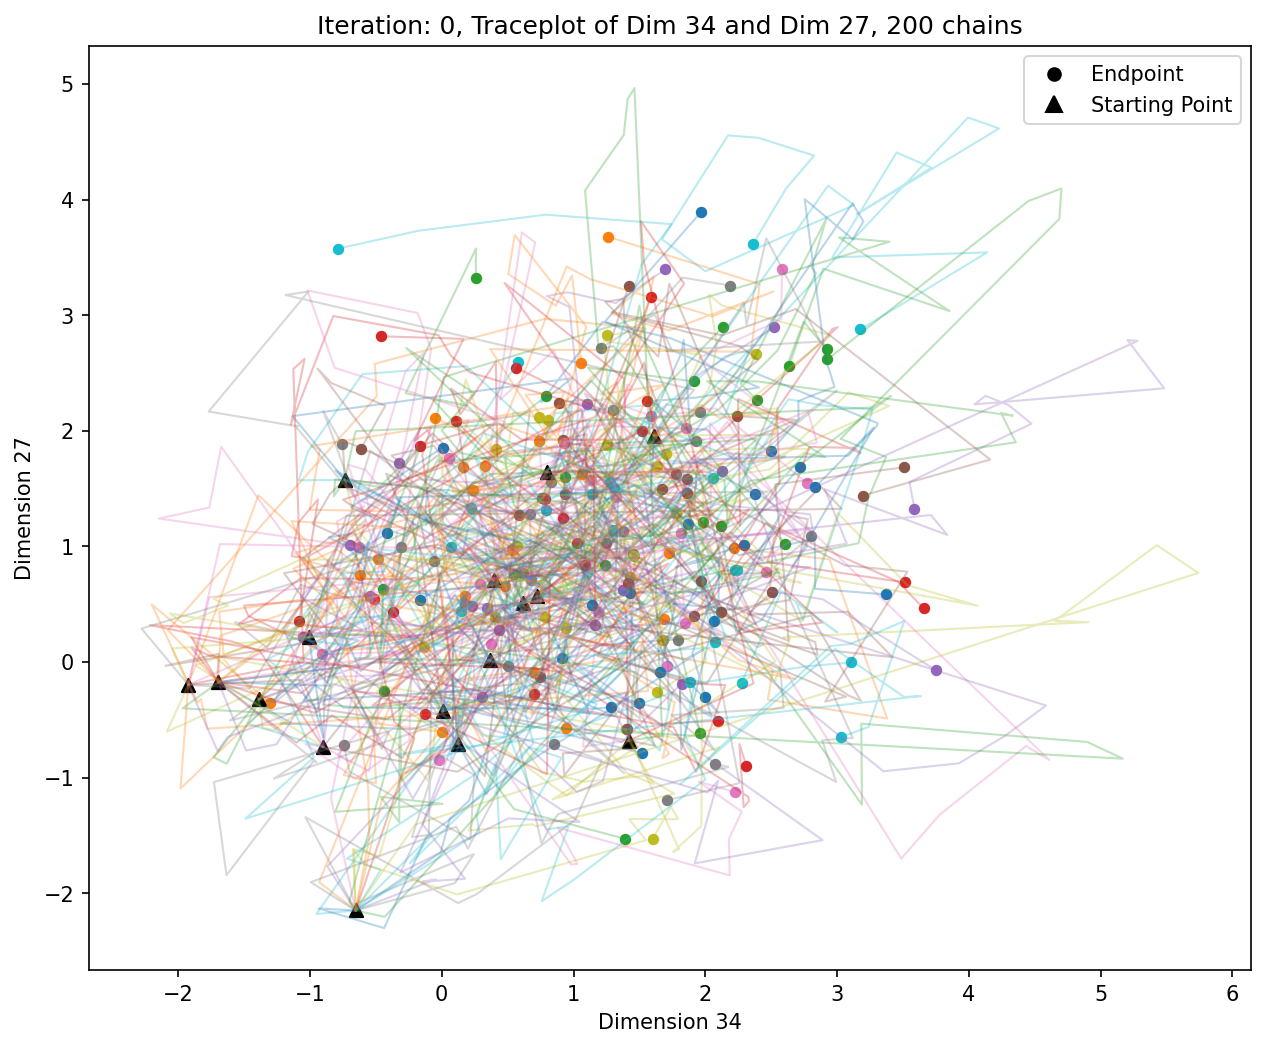

In [ ]:
trace_plot(state_c_df,0,34,27,200,False)

**MVN with AR(1) covariance matrix, $\rho = 0.5$**

In [7]:
num_dim = 100
rho = 0.5
# mean array:
mu = jnp.full(num_dim, 1.3)
# covariance matrix:
cov = [ [rho**(abs(i-j)) for j in range(num_dim)] for i in range(num_dim)]
target = tfd.MultivariateNormalFullCovariance(
      loc=jnp.array(mu),
      covariance_matrix=jnp.array(cov))
init_step_size = 0.5
def target_log_prob_fn(x):
    return target.log_prob(x)
def initialize(shape, key):
    return random.normal(key, shape + (num_dim,))
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

mean_benchmark = target.mean()
var_benchmark = target.variance()

In [11]:
#simulation part:
MSE_constrained_list = []
MSE_naive_list = []
R_Hat_constrained_list = []
R_Hat_naive_list = []
state_list_constrained = []
state_list_naive = []

In [12]:
# 26 min
for length in warmup_length:
  mem(f"Simulation start")
  simulation(
            keys,initialize,
            length,1,
            False, repitition,
            MSE_constrained_list,R_Hat_constrained_list,
            num_dim, state_list_constrained,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size)
  simulation(
            keys,initialize,
            length,1,
            True, repitition,
            MSE_naive_list,R_Hat_naive_list,
            num_dim, state_list_naive,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size)

Simulation start: 1714.0 MB
Constrained initialization. Warmup Length: 10; mean of MSE is: 0.8077495694160461
Naive initialization. Warmup Length: 10; mean of MSE is: 0.8018344044685364
Simulation start: 2241.3 MB
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.38531380891799927
Naive initialization. Warmup Length: 20; mean of MSE is: 0.4002240300178528
Simulation start: 2604.5 MB
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.1312117874622345
Naive initialization. Warmup Length: 30; mean of MSE is: 0.13879069685935974
Simulation start: 3129.1 MB
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.038554269820451736
Naive initialization. Warmup Length: 40; mean of MSE is: 0.04923897609114647
Simulation start: 3813.6 MB
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.005273228045552969
Naive initialization. Warmup Length: 50; mean of MSE is: 0.00796520709991455
Simulation start: 4650.8 MB
Constrained initialization. Warmup

In [14]:
MSE_c_df = pd.DataFrame(MSE_constrained_list)
R_Hat_c_df = pd.DataFrame(R_Hat_constrained_list)
state_c_df = pd.DataFrame(state_list_constrained)
MSE_n_df = pd.DataFrame(MSE_naive_list)
R_Hat_n_df = pd.DataFrame(R_Hat_naive_list)
state_n_df = pd.DataFrame(state_list_naive)

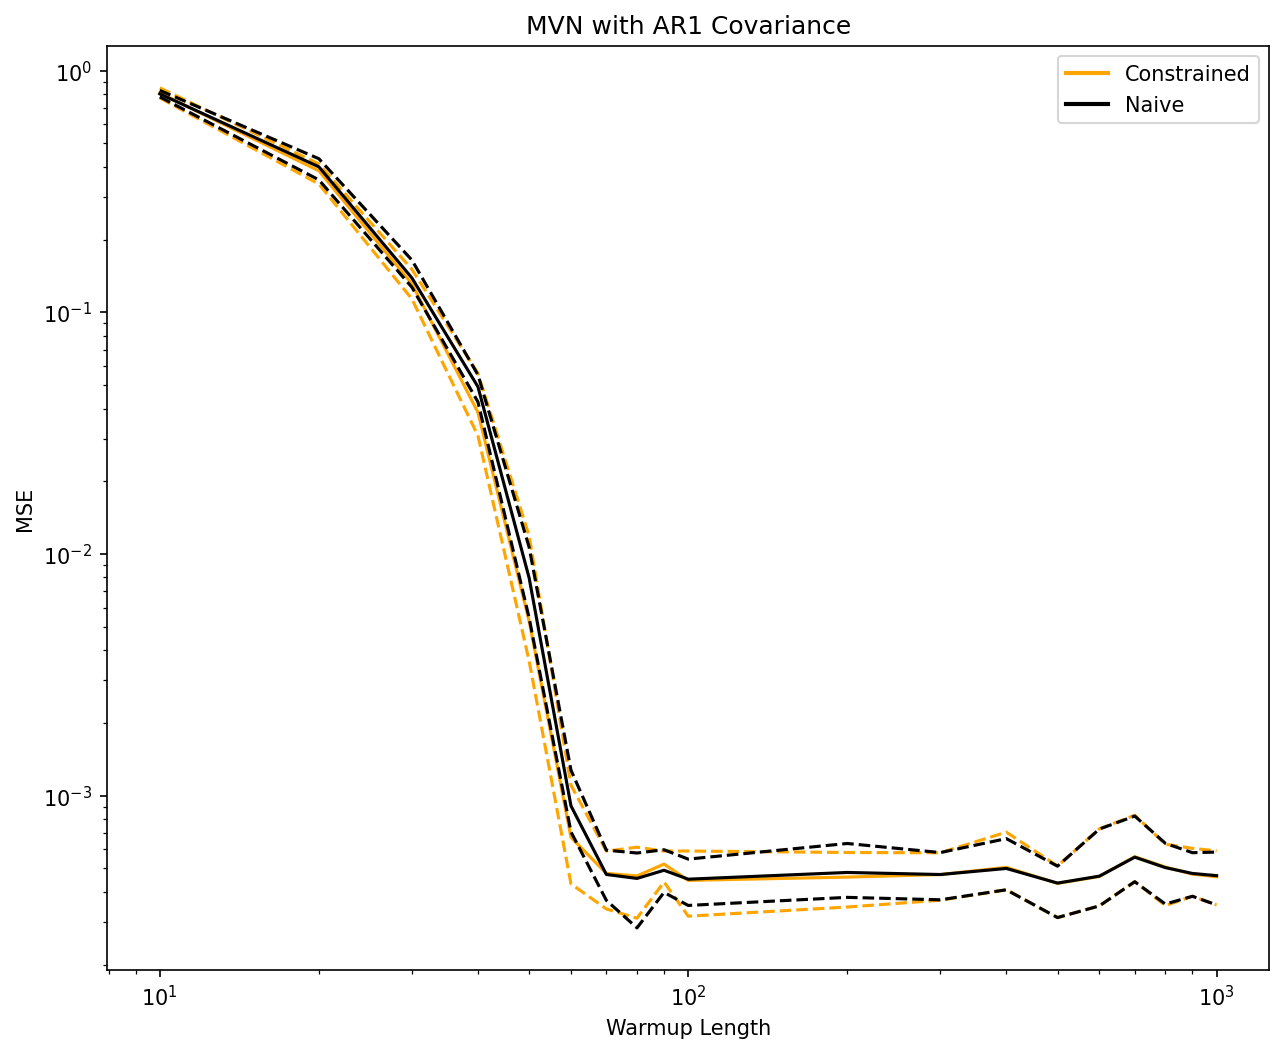

In [16]:
MSE_vs_Warmup(MSE_c_df,
              MSE_n_df,
              "MVN with AR1 Covariance")

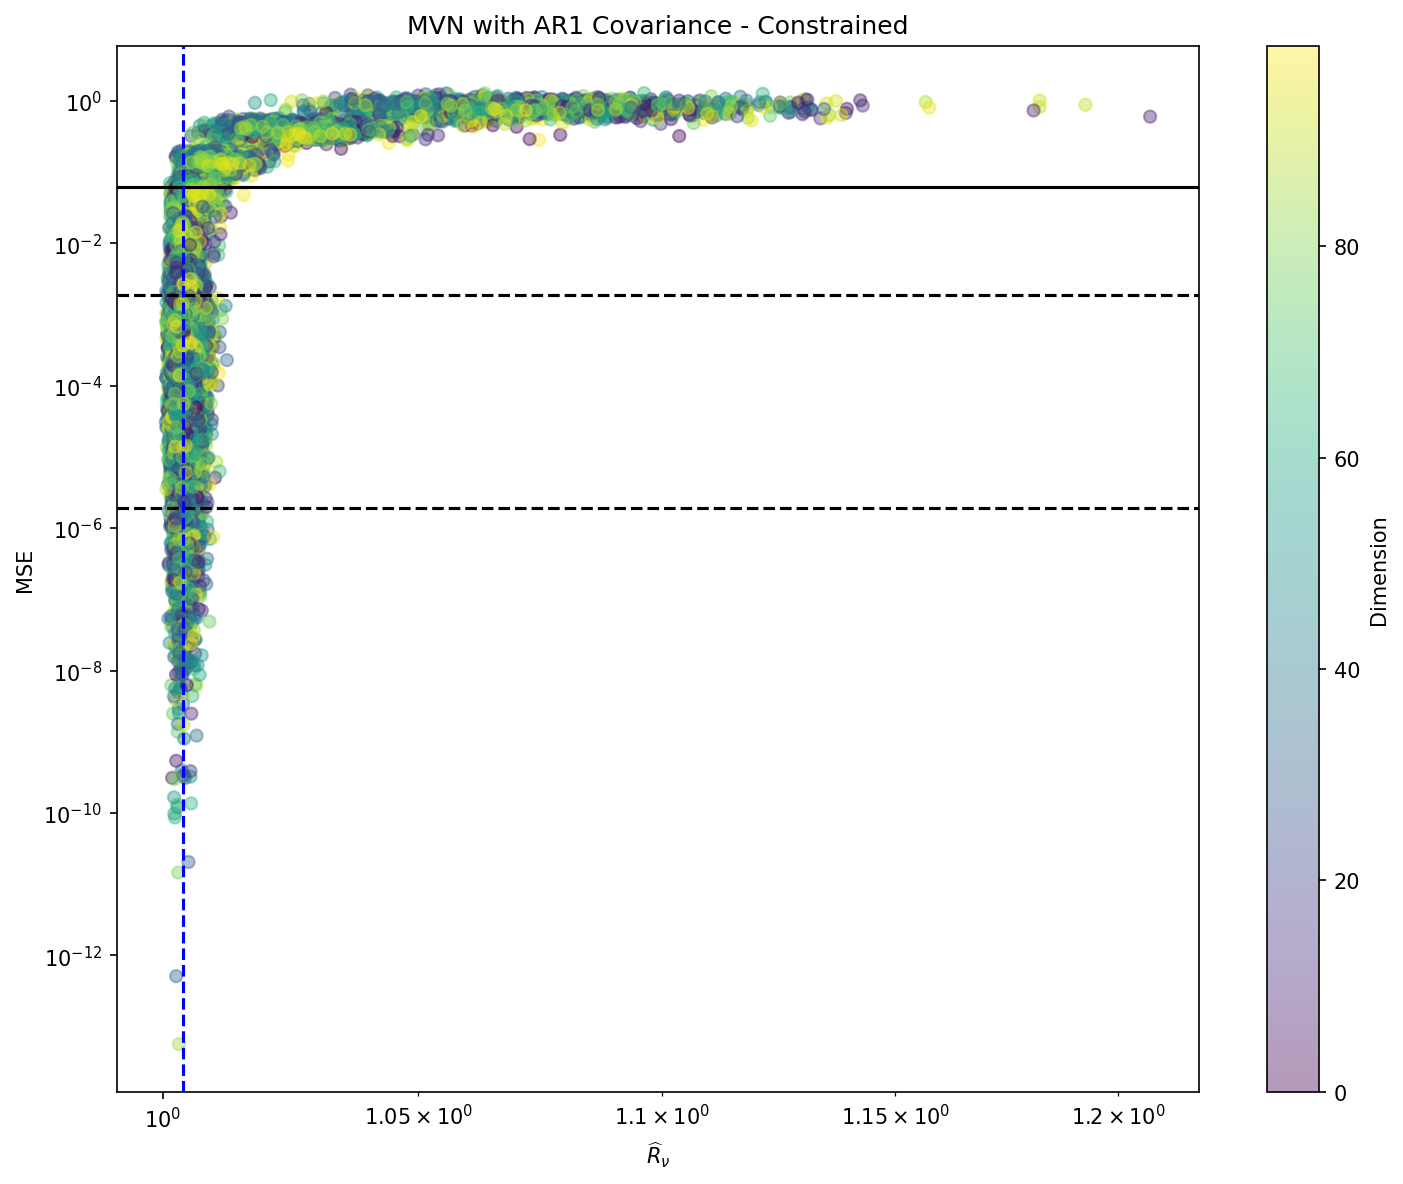

In [17]:
MSE_vs_Rhat(R_Hat_c_df,
           "MVN with AR1 Covariance",
           False,
            bound, threshold,num_super_chains,True)

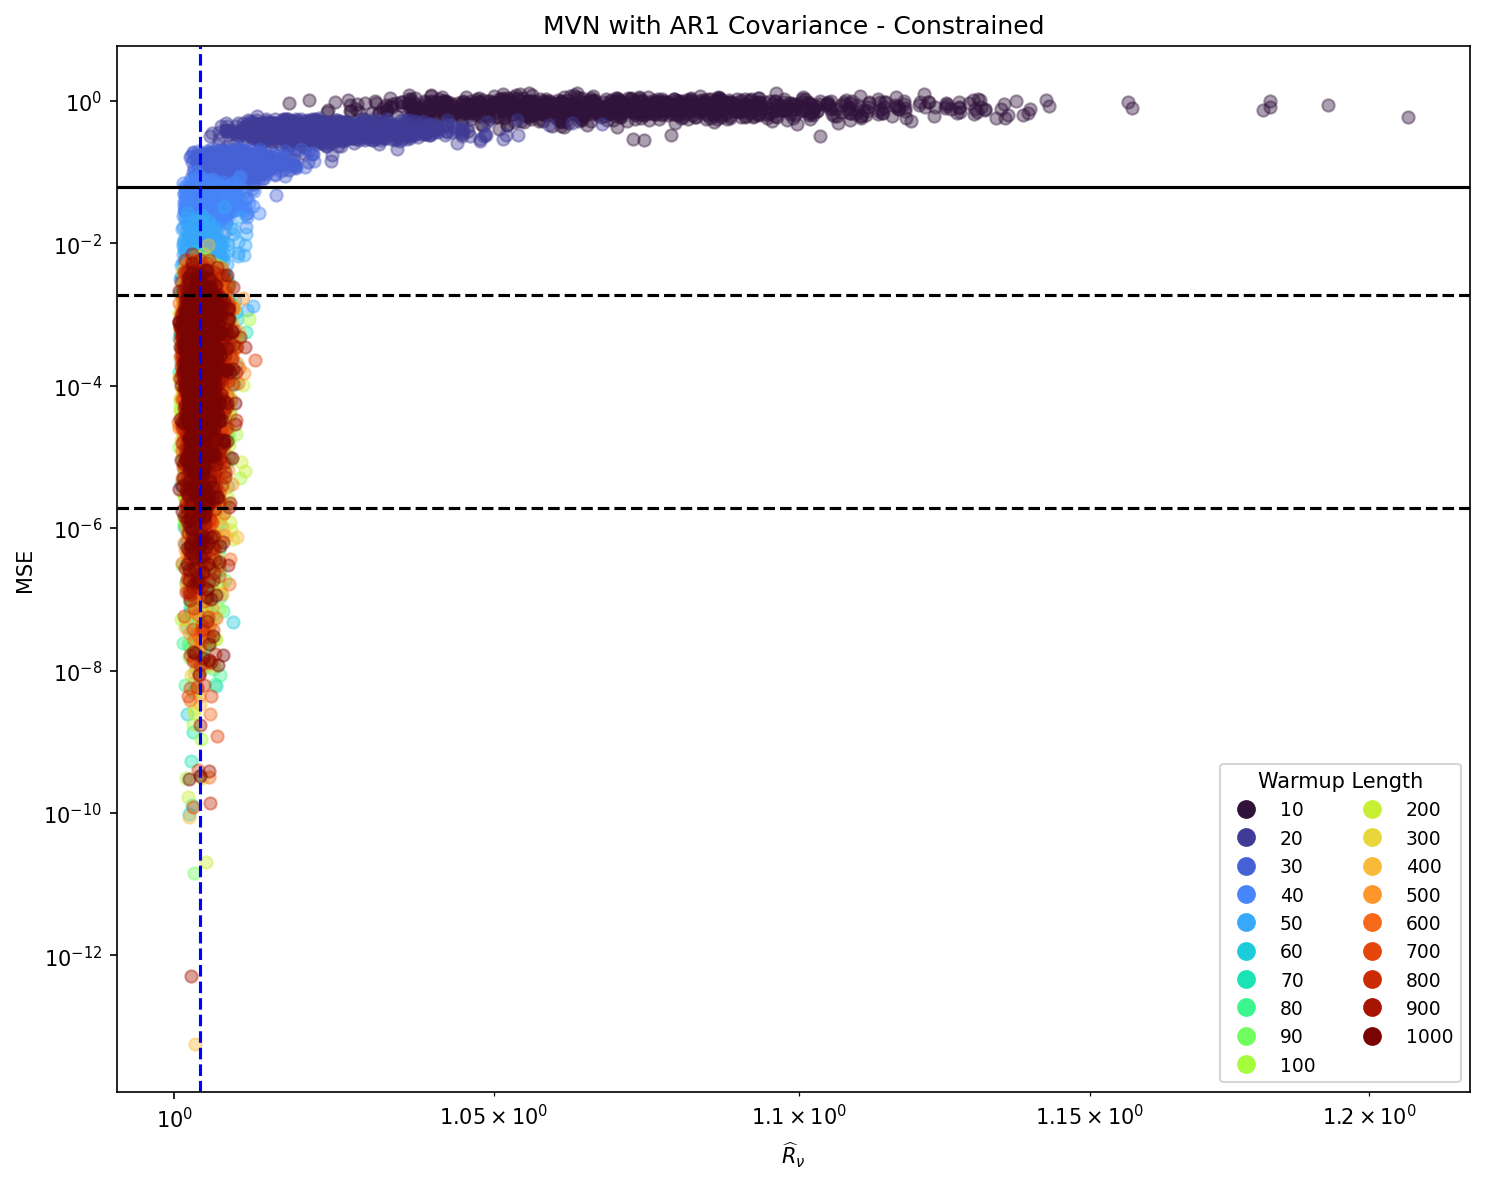

In [18]:
MSE_vs_Rhat(R_Hat_c_df,
           "MVN with AR1 Covariance",
           False,
            bound, threshold,num_super_chains,False)

<Axes: xlabel='Dimension', ylabel='Rhat'>

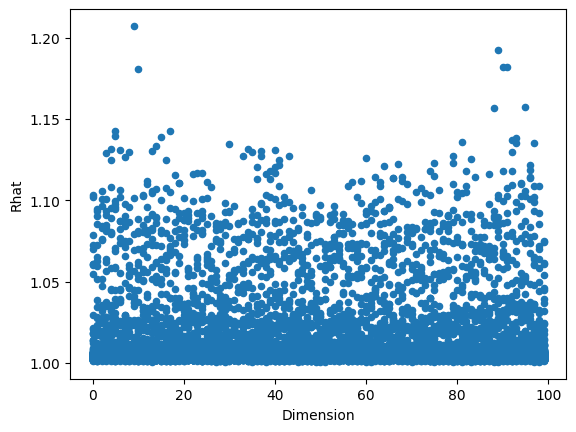

In [19]:
R_Hat_c_df.plot.scatter('Dimension', 'Rhat')

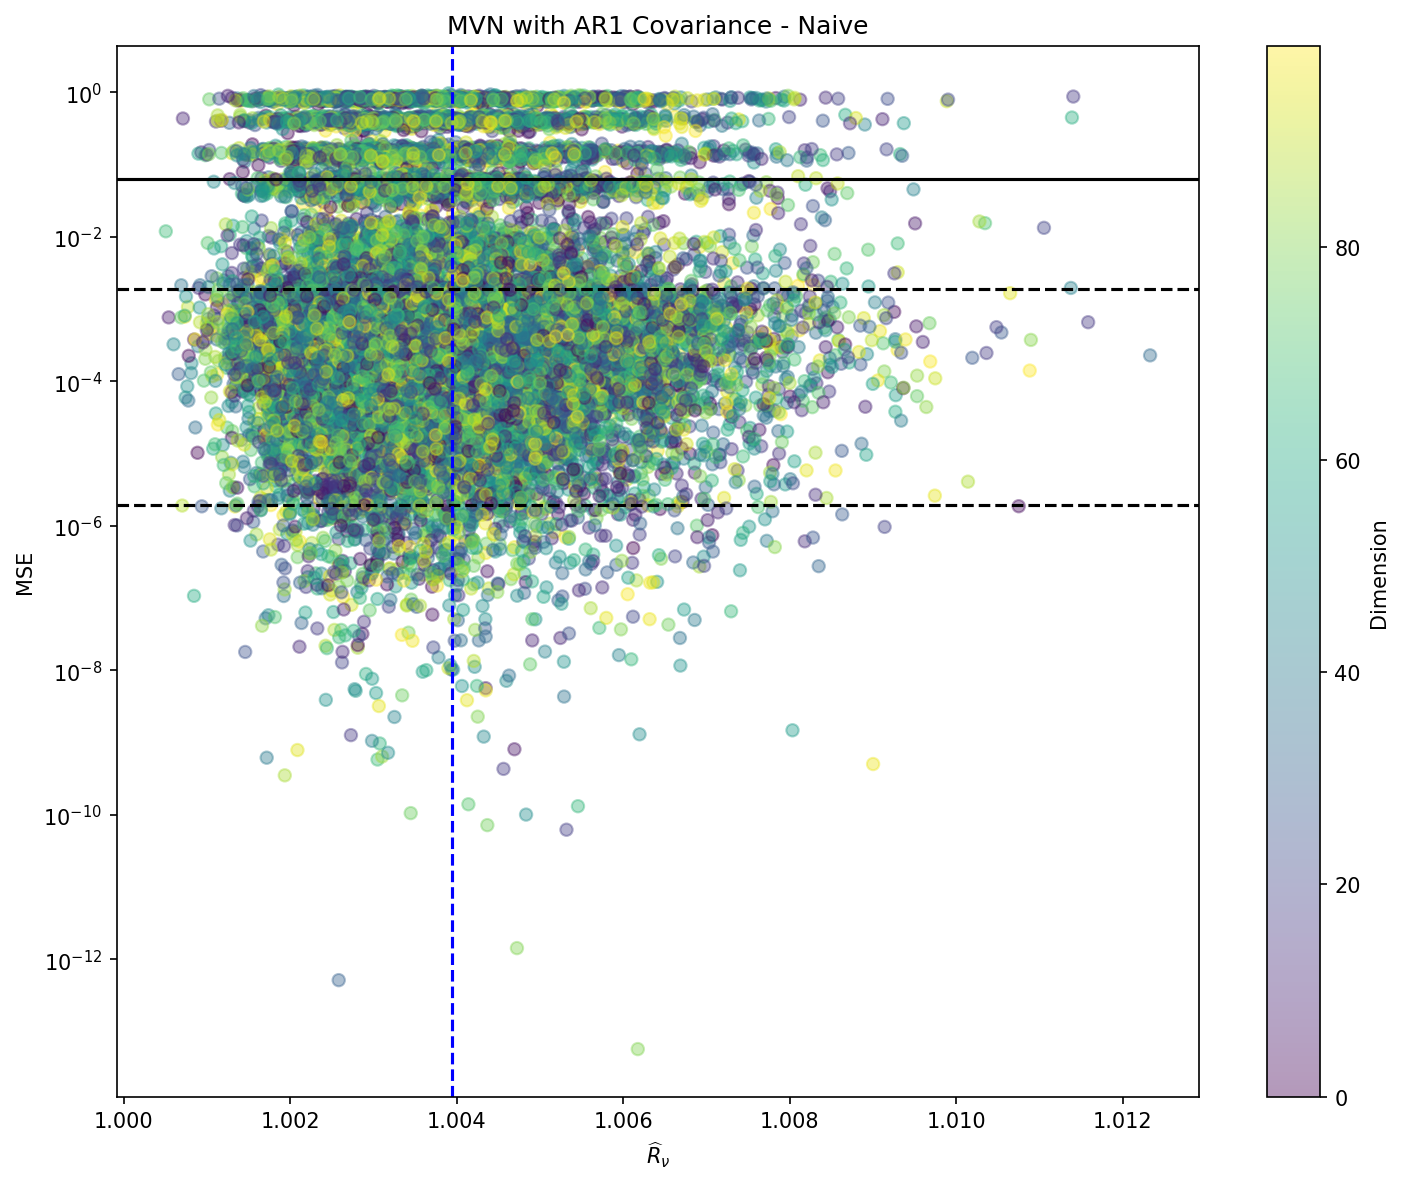

In [20]:
MSE_vs_Rhat(R_Hat_n_df,
           "MVN with AR1 Covariance",
           True,
            bound, threshold,num_super_chains,True)

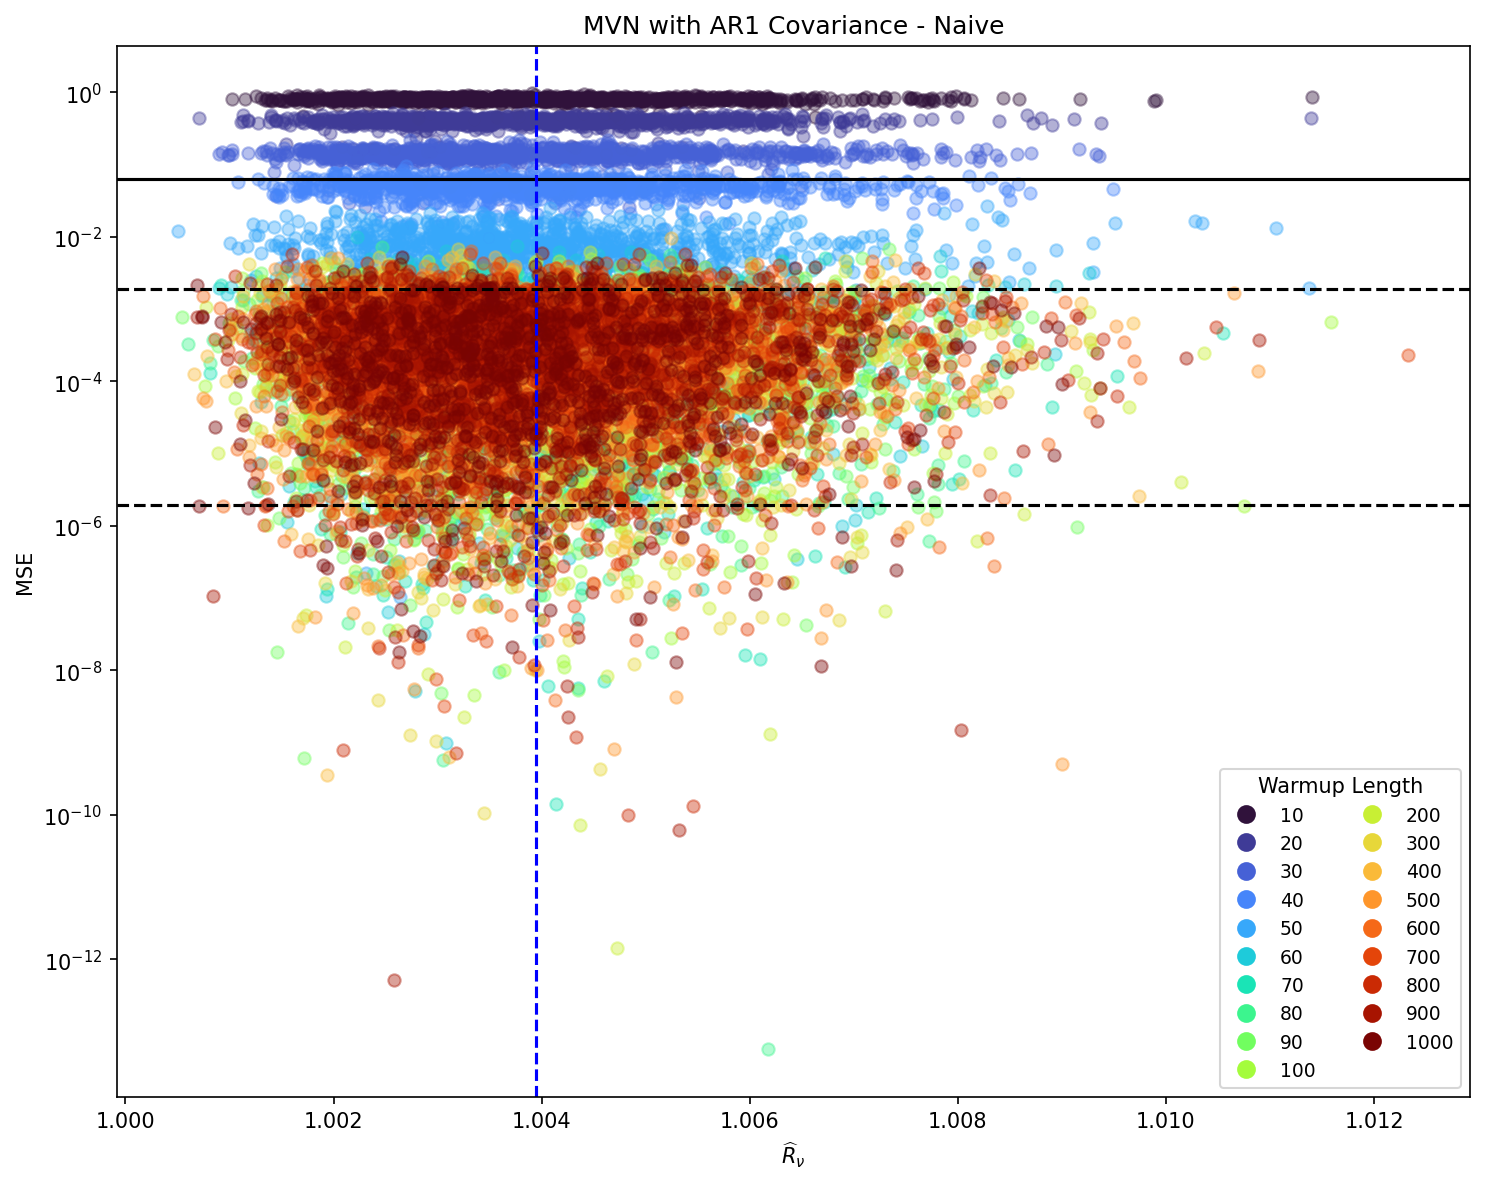

In [21]:
MSE_vs_Rhat(R_Hat_n_df,
           "MVN with AR1 Covariance",
           True,
            bound, threshold,num_super_chains,False)

<Axes: xlabel='Dimension', ylabel='Rhat'>

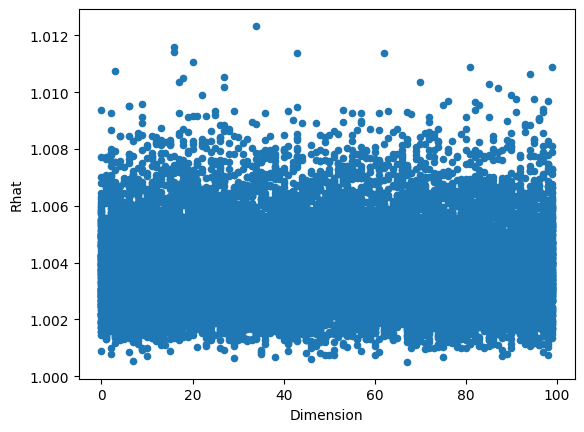

In [22]:
R_Hat_n_df.plot.scatter('Dimension', 'Rhat')

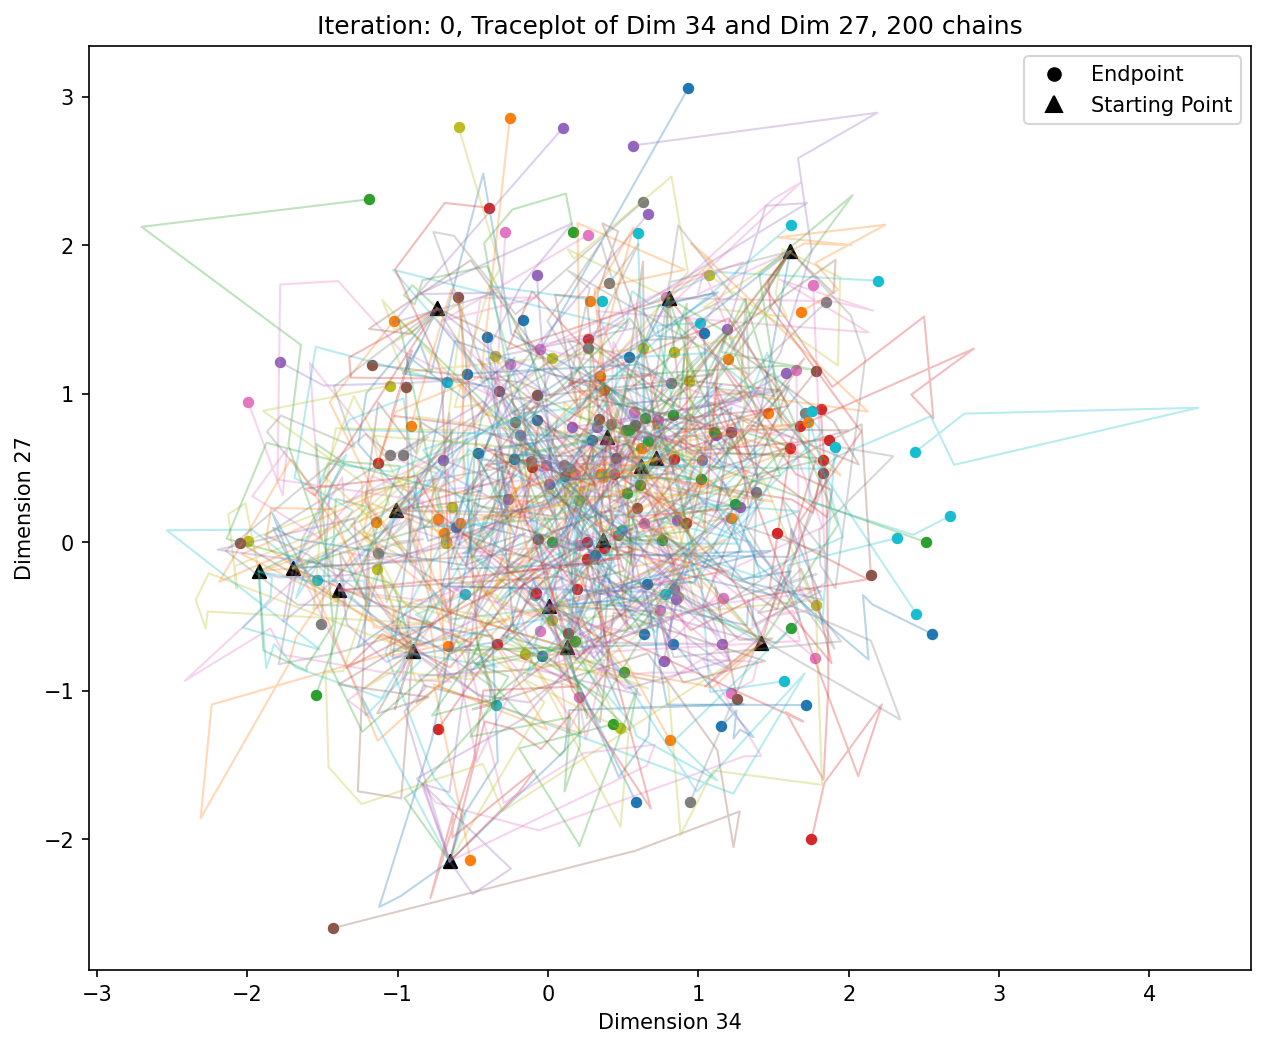

In [23]:
trace_plot(state_c_df,0,34,27,200,False)